In [11]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import gurobipy as gp
from gurobipy import GRB
import warnings
warnings.filterwarnings('ignore')

In [2]:
# ─────────────────────────────────────────────
# 1. LOAD RAW DATA
# ─────────────────────────────────────────────
print("=" * 60)
print("1. LOADING DATA")
print("=" * 60)
 

income     = pd.read_csv("avg_individual_income_nyc.csv")
childcare  = pd.read_csv("child_care_regulated_nyc.csv")
employment = pd.read_csv("employment_rate_nyc.csv")
population = pd.read_csv("population_nyc.csv")
potential  = pd.read_csv("potential_locations_nyc.csv")
 
# Drop unnamed index columns
for df in [income, childcare, employment, population, potential]:
    df.drop(columns=[c for c in df.columns if 'Unnamed' in c], inplace=True)
 
print(f"income:      {income.shape}")
print(f"employment:  {employment.shape}")
print(f"population:  {population.shape}")
print(f"childcare:   {childcare.shape}")
print(f"potential:   {potential.shape}")

1. LOADING DATA
income:      (179, 2)
employment:  (179, 2)
population:  (211, 20)
childcare:   (7740, 15)
potential:   (31100, 3)


In [3]:
# ─────────────────────────────────────────────
# 2. DATA CLEANING
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. DATA CLEANING")
print("=" * 60)
 
# ── 2a. Zipcode alignment ──────────────────────────────────────
z_income = set(income['zipcode'])
z_pop    = set(population['zipcode'])
z_extra  = z_pop - z_income   # 32 zipcodes in pop but not in income/employment
 
# Inspect extra zips: most are PO box / commercial (population = 0)
extra_df = population[population['zipcode'].isin(z_extra)].copy()
meaningful_extra = extra_df[extra_df['Total'] > 0][['zipcode','Total','-5','6-12']]
print(f"\nZipcodes in population but NOT in income/employment: {len(z_extra)}")
print(f"  → {len(z_extra) - len(meaningful_extra)} have zero population (PO boxes/commercial) — dropped")
print(f"  → {len(meaningful_extra)} have non-zero population (handled below):")
print(meaningful_extra.to_string(index=False))
 


2. DATA CLEANING

Zipcodes in population but NOT in income/employment: 32
  → 28 have zero population (PO boxes/commercial) — dropped
  → 4 have non-zero population (handled below):
 zipcode  Total   -5  6-12
   10279    161    0     0
   11249  45087 4774  4836
   11430    332    0    37
   11439   2140    0     0


In [4]:
# 11249: real residential zip — impute income & employment with borough medians
# (Brooklyn — use median of all Brooklyn zips: 11xxx)
bk_mask = (income['zipcode'].between(11200, 11299))
median_income_bk = income[bk_mask]['average income'].median()
median_emp_bk    = employment[employment['zipcode'].between(11200, 11299)]['employment rate'].median()

In [5]:
new_rows_income = pd.DataFrame({'zipcode': [11249], 'average income': [median_income_bk]})
new_rows_emp    = pd.DataFrame({'zipcode': [11249], 'employment rate': [median_emp_bk]})
income     = pd.concat([income, new_rows_income], ignore_index=True)
employment = pd.concat([employment, new_rows_emp], ignore_index=True)
print(f"\n  11249 imputed income = ${median_income_bk:,.0f}, employment rate = {median_emp_bk:.3f}")


  11249 imputed income = $55,444, employment rate = 0.456


In [6]:
# 11430 (JFK area) & 11439: children_0_12 > 0 for 11430 only (37 kids, no 0-5)
# Very small populations — include but they will need minimal intervention
for z, inc, emp in [(11430, median_income_bk, median_emp_bk), (11439, median_income_bk, median_emp_bk)]:
    income     = pd.concat([income,     pd.DataFrame({'zipcode':[z],'average income':[inc]})], ignore_index=True)
    employment = pd.concat([employment, pd.DataFrame({'zipcode':[z],'employment rate':[emp]})], ignore_index=True)

In [7]:
# 10279: very small (161 total, 0 children) — include with imputed values
# Manhattan median
man_mask = income['zipcode'].between(10000, 10299)
median_income_man = income[man_mask]['average income'].median()
median_emp_man    = employment[employment['zipcode'].between(10000,10299)]['employment rate'].median()
income     = pd.concat([income,     pd.DataFrame({'zipcode':[10279],'average income':[median_income_man]})], ignore_index=True)
employment = pd.concat([employment, pd.DataFrame({'zipcode':[10279],'employment rate':[median_emp_man]})], ignore_index=True)

In [8]:
# Working zipcode set: union of income & pop that have actual children
WORKING_ZIPS = set(income['zipcode']) & set(population['zipcode'])
pop_filt = population[population['zipcode'].isin(WORKING_ZIPS)].copy()
# Keep only zips with at least some child population
pop_filt['pop_0_12'] = pop_filt['-5'] + pop_filt['6-12']
WORKING_ZIPS = set(pop_filt[pop_filt['pop_0_12'] > 0]['zipcode'])
print(f"\nWorking zipcode set: {len(WORKING_ZIPS)} zipcodes")
 


Working zipcode set: 180 zipcodes


In [9]:
# ── 2b. Childcare: missing lat/lon ─────────────────────────────
n_missing_ll = childcare['latitude'].isna().sum()
centroid = (childcare.dropna(subset=['latitude','longitude'])
            .groupby('zipcode')[['latitude','longitude']].mean())
childcare['latitude']  = childcare.apply(
    lambda r: centroid.loc[r['zipcode'], 'latitude']  if pd.isna(r['latitude'])  else r['latitude'],  axis=1)
childcare['longitude'] = childcare.apply(
    lambda r: centroid.loc[r['zipcode'], 'longitude'] if pd.isna(r['longitude']) else r['longitude'], axis=1)
print(f"\nChildcare lat/lon: {n_missing_ll} missing → imputed using zipcode centroid")
print(f"  Remaining nulls: {childcare['latitude'].isna().sum()}")


Childcare lat/lon: 169 missing → imputed using zipcode centroid
  Remaining nulls: 0


In [10]:
# ── 2c. Filter to active (non-suspended/revoked) facilities ────
bad_status = ['Suspended', 'Pending Revocation', 'Pending Revocation and Denial']
n_before = len(childcare)
childcare_active = childcare[~childcare['facility_status'].isin(bad_status)].copy()
print(f"\nRemoved {n_before - len(childcare_active)} facilities with bad status")
print(f"Active facilities: {len(childcare_active)}")


Removed 27 facilities with bad status
Active facilities: 7713


In [11]:
# ── 2d. Capacity columns ───────────────────────────────────────
# total_capacity = infant + toddler + preschool + school_age + children
# slots_0_5 = infant + toddler + preschool + children_capacity (FDC/GFDC serve 0-5)
# slots_school_age = school_age_capacity
childcare_active['slots_0_5'] = (childcare_active['children_capacity'] +
                                  childcare_active['preschool_capacity'] +
                                  childcare_active['infant_capacity'] +
                                  childcare_active['toddler_capacity'])

In [12]:
# ─────────────────────────────────────────────
# 3. BUILD ZIPCODE-LEVEL SUMMARY
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("3. BUILDING ZIPCODE SUMMARY")
print("=" * 60)
 
# Aggregate childcare
cc_zip = (childcare_active[childcare_active['zipcode'].isin(WORKING_ZIPS)]
          .groupby('zipcode')
          .agg(n_facilities=('facility_id','count'),
               total_slots=('total_capacity','sum'),
               slots_0_5=('slots_0_5','sum'))
          .reset_index())
 
# Build master df
pop_clean = pop_filt[pop_filt['zipcode'].isin(WORKING_ZIPS)][['zipcode','-5','6-12','pop_0_12']].copy()
pop_clean.columns = ['zipcode','pop_0_5','pop_6_12','pop_0_12']
 
df = (income[income['zipcode'].isin(WORKING_ZIPS)][['zipcode','average income']]
      .merge(employment[employment['zipcode'].isin(WORKING_ZIPS)][['zipcode','employment rate']], on='zipcode')
      .merge(pop_clean, on='zipcode')
      .merge(cc_zip, on='zipcode', how='left'))
 
df['n_facilities'] = df['n_facilities'].fillna(0).astype(int)
df['total_slots']  = df['total_slots'].fillna(0).astype(int)
df['slots_0_5']    = df['slots_0_5'].fillna(0).astype(int)
 
print(f"Master dataframe: {df.shape}")


3. BUILDING ZIPCODE SUMMARY
Master dataframe: (180, 9)


In [13]:
df

,zipcode,average income,employment rate,pop_0_5,pop_6_12,pop_0_12,n_facilities,total_slots,slots_0_5
0,10001,102878.033603,0.595097,744,1255,1999,9,609,24
1,10002,59604.041165,0.520662,2142,4645,6787,56,4724,216
2,10003,114273.049645,0.497244,1440,1510,2950,7,1995,0
3,10004,132004.310345,0.506661,433,262,695,2,263,0
4,10005,121437.713311,0.665833,484,318,802,1,39,0
...,...,...,...,...,...,...,...,...,...
175,11693,61620.926244,0.430004,681,1096,1777,4,328,12
176,11694,84441.939121,0.407105,1366,2103,3469,8,752,30
177,11697,100870.901639,0.618348,230,317,547,0,0,0
178,11249,55444.328669,0.455889,4774,4836,9610,10,315,96


In [14]:
# ── Desert classification ──────────────────────────────────────
df['high_demand']  = (df['employment rate'] >= 0.6) | (df['average income'] <= 60000)
df['desert_threshold'] = np.where(df['high_demand'], 0.5 * df['pop_0_12'], (1/3) * df['pop_0_12'])
df['is_desert']    = df['total_slots'] <= df['desert_threshold']


In [15]:
# Slot deficit to escape desert status (need strictly > threshold)
df['total_deficit'] = np.where(
    df['is_desert'],
    (np.ceil(df['desert_threshold']) + 1 - df['total_slots']).clip(lower=0),
    0
).astype(int)

In [16]:
# Under-5 constraint: slots_0_5 >= (2/3) * pop_0_5
df['under5_required'] = np.ceil((2/3) * df['pop_0_5']).astype(int)
df['under5_deficit']  = (df['under5_required'] - df['slots_0_5']).clip(lower=0).astype(int)
df['fails_under5']    = df['slots_0_5'] < df['under5_required']
 
print(f"\nChild care deserts: {df['is_desert'].sum()} / {len(df)} zipcodes ({df['is_desert'].mean():.1%})")
print(f"  High-demand deserts: {df[df['high_demand'] & df['is_desert']].shape[0]}")
print(f"  Normal-demand deserts: {df[~df['high_demand'] & df['is_desert']].shape[0]}")
print(f"\nFailing under-5 constraint: {df['fails_under5'].sum()} / {len(df)} zipcodes")
print(f"\nTotal slot deficit (across all deserts): {df['total_deficit'].sum():,}")
print(f"Total under-5 deficit: {df['under5_deficit'].sum():,}")


Child care deserts: 162 / 180 zipcodes (90.0%)
  High-demand deserts: 91
  Normal-demand deserts: 71

Failing under-5 constraint: 179 / 180 zipcodes

Total slot deficit (across all deserts): 238,154
Total under-5 deficit: 277,184



4. GENERATING VISUALIZATIONS


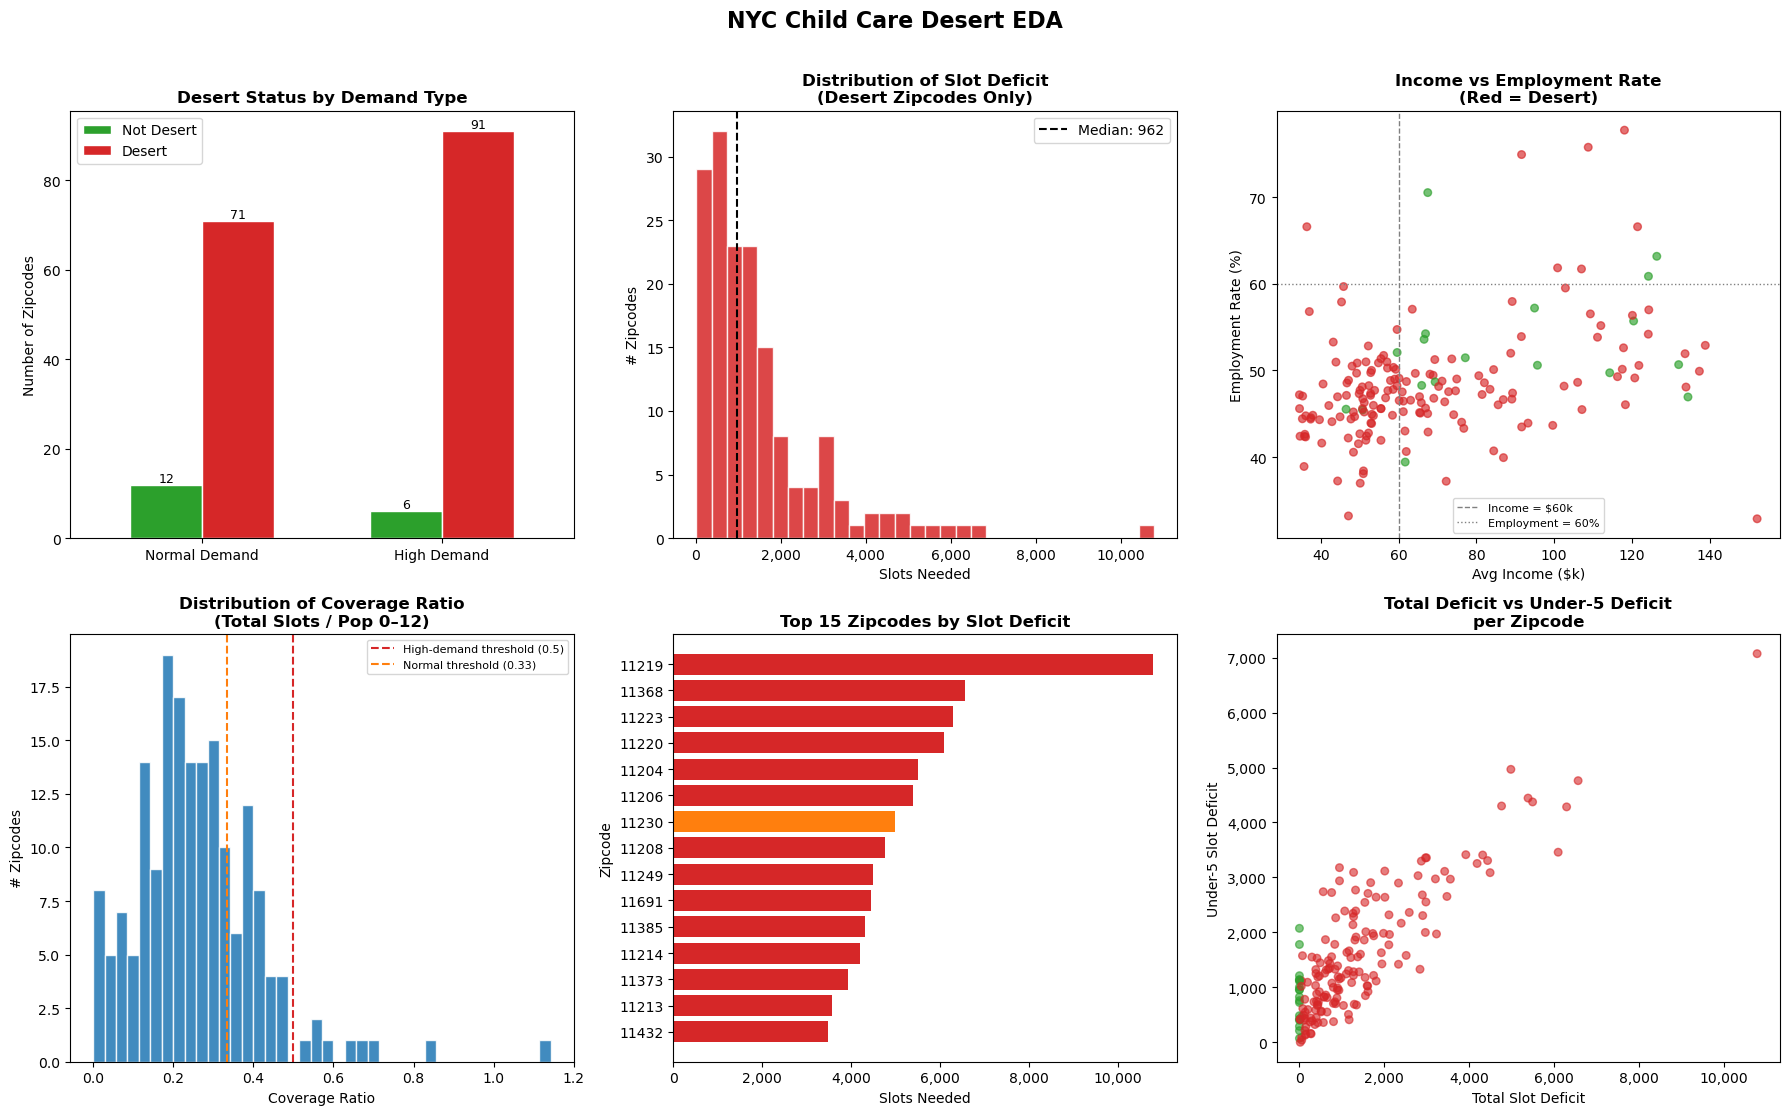

In [17]:
# ─────────────────────────────────────────────
# 4. EDA VISUALIZATIONS
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("4. GENERATING VISUALIZATIONS")
print("=" * 60)
 
fig, axes = plt.subplots(2, 3, figsize=(18, 11))
fig.suptitle("NYC Child Care Desert EDA", fontsize=16, fontweight='bold', y=1.01)
 
palette = {'desert': '#d62728', 'ok': '#2ca02c', 'high': '#ff7f0e', 'normal': '#1f77b4'}


# ── Plot 1: Desert status by demand type ──────────────────────
ax = axes[0, 0]
counts = df.groupby(['high_demand', 'is_desert']).size().unstack(fill_value=0)
counts.index = ['Normal Demand', 'High Demand']
counts.columns = ['Not Desert', 'Desert']
counts.plot(kind='bar', ax=ax, color=[palette['ok'], palette['desert']], edgecolor='white', width=0.6)
ax.set_title('Desert Status by Demand Type', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('Number of Zipcodes')
ax.set_xticklabels(counts.index, rotation=0)
ax.legend()
for c in ax.containers:
    ax.bar_label(c, fontsize=9)


# ── Plot 2: Distribution of slot deficit ──────────────────────
ax = axes[0, 1]
deficit_nonzero = df[df['total_deficit'] > 0]['total_deficit']
ax.hist(deficit_nonzero, bins=30, color=palette['desert'], edgecolor='white', alpha=0.85)
ax.axvline(deficit_nonzero.median(), color='black', linestyle='--', linewidth=1.5, label=f'Median: {deficit_nonzero.median():.0f}')
ax.set_title('Distribution of Slot Deficit\n(Desert Zipcodes Only)', fontweight='bold')
ax.set_xlabel('Slots Needed')
ax.set_ylabel('# Zipcodes')
ax.legend()
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))



# ── Plot 3: Income vs Employment scatter, colored by desert ───
ax = axes[0, 2]
colors = df['is_desert'].map({True: palette['desert'], False: palette['ok']})
ax.scatter(df['average income']/1000, df['employment rate']*100, c=colors, alpha=0.65, s=30)
ax.axvline(60, color='gray', linestyle='--', linewidth=1, label='Income = $60k')
ax.axhline(60, color='gray', linestyle=':', linewidth=1, label='Employment = 60%')
ax.set_title('Income vs Employment Rate\n(Red = Desert)', fontweight='bold')
ax.set_xlabel('Avg Income ($k)')
ax.set_ylabel('Employment Rate (%)')
ax.legend(fontsize=8)
 
# ── Plot 4: Coverage ratio distribution ───────────────────────
ax = axes[1, 0]
df['coverage_ratio'] = df['total_slots'] / df['pop_0_12'].replace(0, np.nan)
ax.hist(df['coverage_ratio'].dropna(), bins=40, color=palette['normal'], edgecolor='white', alpha=0.85)
ax.axvline(0.5, color=palette['desert'], linestyle='--', linewidth=1.5, label='High-demand threshold (0.5)')
ax.axvline(1/3, color=palette['high'], linestyle='--', linewidth=1.5, label='Normal threshold (0.33)')
ax.set_title('Distribution of Coverage Ratio\n(Total Slots / Pop 0–12)', fontweight='bold')
ax.set_xlabel('Coverage Ratio')
ax.set_ylabel('# Zipcodes')
ax.legend(fontsize=8)
 
# ── Plot 5: Top 15 worst deserts ──────────────────────────────
ax = axes[1, 1]
top15 = df.nlargest(15, 'total_deficit')[['zipcode','total_deficit','high_demand']].copy()
top15['zipcode'] = top15['zipcode'].astype(str)
bar_colors = top15['high_demand'].map({True: palette['desert'], False: palette['high']})
ax.barh(top15['zipcode'][::-1], top15['total_deficit'][::-1], color=bar_colors.values[::-1])
ax.set_title('Top 15 Zipcodes by Slot Deficit', fontweight='bold')
ax.set_xlabel('Slots Needed')
ax.set_ylabel('Zipcode')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
 
# ── Plot 6: Under-5 deficit vs total deficit ──────────────────
ax = axes[1, 2]
ax.scatter(df['total_deficit'], df['under5_deficit'],
           c=df['is_desert'].map({True: palette['desert'], False: palette['ok']}),
           alpha=0.6, s=30)
ax.set_title('Total Deficit vs Under-5 Deficit\nper Zipcode', fontweight='bold')
ax.set_xlabel('Total Slot Deficit')
ax.set_ylabel('Under-5 Slot Deficit')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
 
plt.tight_layout()

In [18]:
# 5. SUMMARY STATS TABLE
# ─────────────────────────────────────────────
print("\n" + "=" * 60)
print("5. KEY SUMMARY STATISTICS")
print("=" * 60)
 
summary = {
    'Total zipcodes (working)': len(df),
    'High-demand zipcodes': int(df['high_demand'].sum()),
    'Normal-demand zipcodes': int((~df['high_demand']).sum()),
    'Child care deserts': int(df['is_desert'].sum()),
    '  - High-demand deserts': int(df[df['high_demand'] & df['is_desert']].shape[0]),
    '  - Normal-demand deserts': int(df[~df['high_demand'] & df['is_desert']].shape[0]),
    'Total active facilities': int(df['n_facilities'].sum()),
    'Total existing slots (all)': int(df['total_slots'].sum()),
    'Total existing slots (0-5)': int(df['slots_0_5'].sum()),
    'Total pop 0-12': int(df['pop_0_12'].sum()),
    'Total pop 0-5': int(df['pop_0_5'].sum()),
    'Total slot deficit (deserts)': int(df['total_deficit'].sum()),
    'Total under-5 deficit': int(df['under5_deficit'].sum()),
    'Zipcodes failing under-5 rule': int(df['fails_under5'].sum()),
}
for k, v in summary.items():
    print(f"  {k:<40} {v:>10,}")
 
# Save clean data
df.to_csv('zipcode_master.csv', index=False)
childcare_active.to_csv('childcare_clean.csv', index=False)
print("\nSaved: zipcode_master.csv, childcare_clean.csv")


5. KEY SUMMARY STATISTICS
  Total zipcodes (working)                        180
  High-demand zipcodes                             97
  Normal-demand zipcodes                           83
  Child care deserts                              162
    - High-demand deserts                          91
    - Normal-demand deserts                        71
  Total active facilities                       7,709
  Total existing slots (all)                  317,295
  Total existing slots (0-5)                   69,690
  Total pop 0-12                            1,239,727
  Total pop 0-5                               520,214
  Total slot deficit (deserts)                238,154
  Total under-5 deficit                       277,184
  Zipcodes failing under-5 rule                   179

Saved: zipcode_master.csv, childcare_clean.csv


## Problem 1: Idealistic Budgeting

### Sets and Indices

$$
\begin{aligned}
&Z \quad \text{set of zipcodes} \\
&F \quad \text{set of existing active facilities}, \quad F(z) \subseteq F \text{ facilities in zipcode } z \\
&S = \{\text{small, medium, large}\} \quad \text{set of new facility sizes}
\end{aligned}
$$

---

### Parameters

$$
\begin{aligned}
&n_f \quad &&\text{current number of slots at facility } f \\
&s_f \quad &&\text{current number of under-5 slots at facility } f \\
&P_z \quad &&\text{total child population (ages 0--12) in zipcode } z \\
&P_z^{05} \quad &&\text{child population aged 0--5 in zipcode } z \\
&T_z \quad &&\text{existing total slots in zipcode } z \\
&T_z^{05} \quad &&\text{existing under-5 slots in zipcode } z \\
&R_z \quad &&\text{required total slots to eliminate desert in zipcode } z \\
&R_z^{05} = \left\lceil \tfrac{2}{3} P_z^{05} \right\rceil \quad &&\text{required under-5 slots in zipcode } z \\
&\bar{x}_f = \min(0.2\, n_f,\ 500) \quad &&\text{expansion cap (added slots) for facility } f \\
&c_{\text{slots}}(n_f) \quad &&\text{per-slot expansion cost (piece 1), decreasing step function of } n_f \\[4pt]
& &&c_{\text{slots}}(n_f) = \begin{cases}
1200 & n_f \leq 20 \\
600  & 20 < n_f \leq 50 \\
400  & 50 < n_f \leq 100 \\
300  & 100 < n_f \leq 200 \\
\frac{20000}{n_f} + 200 & n_f > 200
\end{cases} \\[6pt]
&\text{cap}_s,\ \text{cap}^{05}_s \quad &&\text{total and under-5 slot capacity of a size-}s\text{ facility} \\
&\text{cost}_s \quad &&\text{construction cost of a size-}s\text{ facility} \\
&e = \$100 \quad &&\text{equipment cost per under-5 slot}
\end{aligned}
$$

---

### Decision Variables

$$
\begin{aligned}
&x^1_f \geq 0 \quad &&\text{slots added to facility } f \text{ in piece-1 range } (x_f < n_f) \\
&x^2_f \geq 0 \quad &&\text{slots added to facility } f \text{ in piece-2 range } (x_f \geq n_f) \\
&u_f \geq 0 \quad &&\text{under-5 slots added to facility } f \\
&y_{zs} \geq 0, \text{ integer} \quad &&\text{number of size-}s\text{ facilities built in zipcode } z
\end{aligned}
$$

---

### Objective Function

Minimize total cost:

$$
\min \quad
\underbrace{\sum_{f \in F} \left[ c_{\text{slots}}(n_f)\cdot x^1_f \ + \ \frac{20000 + 200\,n_f}{n_f}\cdot x^2_f \ + \ e \cdot u_f \right]}_{\text{expansion cost (existing facilities)}}
\ + \
\underbrace{\sum_{z \in Z}\sum_{s \in S} \left( \text{cost}_s + e \cdot \text{cap}^{05}_s \right) y_{zs}}_{\text{new facility cost}}
$$

where the two piece costs satisfy:

$$
c_{\text{slots}}(n_f) \leq \frac{20000 + 200\,n_f}{n_f} \qquad \forall f \in F
$$

This inequality ensures piece 1 is always cheaper than piece 2, so the LP solver
naturally exhausts $x^1_f$ before using $x^2_f$ — no binary variables required.

---

### Constraints

**1. Piece-1 range cap:**
$$
x^1_f \leq n_f \qquad \forall f \in F
$$

**2. Total expansion cap:**
$$
x^1_f + x^2_f \leq \bar{x}_f \qquad \forall f \in F
$$

**3. Under-5 expansion bound:**
$$
u_f \leq x^1_f + x^2_f \qquad \forall f \in F
$$

**4. Desert elimination per zipcode:**
$$
T_z + \sum_{f \in F(z)} \left( x^1_f + x^2_f \right) + \sum_{s \in S} \text{cap}_s \cdot y_{zs} \geq R_z \qquad \forall z \in Z
$$

**5. Under-5 coverage per zipcode:**
$$
T_z^{05} + \sum_{f \in F(z)} u_f + \sum_{s \in S} \text{cap}^{05}_s \cdot y_{zs} \geq R_z^{05} \qquad \forall z \in Z
$$

**6. Non-negativity and integrality:**
$$
x^1_f,\ x^2_f,\ u_f \geq 0 \qquad \forall f \in F
$$
$$
y_{zs} \in \mathbb{Z}_{\geq 0} \qquad \forall z \in Z,\ s \in S
$$

---

### Desert Classification

The required slot threshold $R_z$ depends on whether zipcode $z$ is high-demand or normal-demand:

$$
R_z = \begin{cases}
\left\lfloor \tfrac{1}{2} (P_z^{0} + P_z^{6}) \right\rfloor + 1 & \text{if } \text{emp}_z \geq 0.6 \text{ or } \text{inc}_z \leq \$60{,}000 \quad \text{(high-demand)} \\[6pt]
\left\lfloor \tfrac{1}{3} (P_z^{0} + P_z^{6}) \right\rfloor + 1 & \text{otherwise} \quad \text{(normal-demand)}
\end{cases}
$$

where $P_z^{0}$ and $P_z^{6}$ denote the population of children aged 0--5 and 6--12 respectively.

"New slots" could mean both — any newly added under-5 slot, whether via expansion or new build. Our interpretation is more conservative (higher cost) but arguably more correct. This is worth a note in your report as an assumption.

In [12]:
df= pd.read_csv('zipcode_master.csv')
childcare = pd.read_csv('childcare_clean.csv')
 
# Only keep zipcodes in working set
ZIPS = set(df['zipcode'].tolist())
childcare = childcare[childcare['zipcode'].isin(ZIPS)].copy()
df = df[df['zipcode'].isin(ZIPS)].copy()
 
print(f"Working zipcodes: {len(ZIPS)}")
print(f"Existing facilities: {len(childcare)}")

Working zipcodes: 180
Existing facilities: 7709


In [17]:
# 2. PARAMETERS
# ─────────────────────────────────────────────
SIZES = {
    'small':  {'cap': 100, 'cap05': 50,  'cost': 65_000},
    'medium': {'cap': 200, 'cap05': 100, 'cost': 95_000},
    'large':  {'cap': 400, 'cap05': 200, 'cost': 115_000},
}
 
def c_slots(n):
    if n <= 20:    return 20000/20  + 200   # 1200
    elif n <= 50:  return 20000/50  + 200   # 600
    elif n <= 100: return 20000/100 + 200   # 400
    elif n <= 200: return 20000/200 + 200   # 300
    else:          return 20000/n   + 200   # per-facility
 
# Facility-level parameters
fac = childcare[['facility_id','zipcode','total_capacity','slots_0_5']].copy()
fac = fac[fac['total_capacity'] > 0].copy()
fac['nf']       = fac['total_capacity']
fac['max_exp']  = np.minimum(1.2 * fac['nf'], fac['nf'] + 500)
fac['cs']       = fac['nf'].apply(c_slots)
fac['p2_slope'] = 20000 / fac['nf'] + 200
fac_dict        = fac.set_index('facility_id')
 
# Zipcode-level requirements
zip_stats = df.set_index('zipcode')[
    ['pop_0_5','pop_0_12','high_demand','desert_threshold',
     'total_slots','slots_0_5']
].copy()
zip_stats['req_total'] = (np.floor(zip_stats['desert_threshold']) + 1).astype(int)
zip_stats['req_0_5']   = np.ceil((2/3) * zip_stats['pop_0_5']).astype(int)
 
fac_by_zip = fac.groupby('zipcode')['facility_id'].apply(list).to_dict()
facilities = fac['facility_id'].tolist()
zips       = list(ZIPS)
sizes      = list(SIZES.keys())
 
print(f"Facilities (nf>0):   {len(facilities)}")

Facilities (nf>0):   7708


In [20]:
 #─────────────────────────────────────────────
# 3. BUILD GUROBI MODEL
# ─────────────────────────────────────────────
print("\nBuilding Gurobi model...")
m = gp.Model("ChildCareDeserts_P1")
m.setParam('OutputFlag', 1)
m.setParam('TimeLimit', 300)
 
# ── Decision variables ────────────────────────
# x1[f]: slots added in piece-1 range (xf < nf), x2[f]: piece-2 range (xf >= nf)
x1 = m.addVars(facilities, lb=0.0, name="x1")
x2 = m.addVars(facilities, lb=0.0, name="x2")
u  = m.addVars(facilities, lb=0.0, name="u")   # under-5 slots added
 
# y[z,s]: new facilities of size s in zipcode z (integer)
y  = m.addVars(zips, sizes, lb=0, vtype=GRB.INTEGER, name="y")
 
# ── Objective ─────────────────────────────────
expansion_cost = gp.quicksum(
    fac_dict.loc[f, 'cs']       * x1[f] +
    fac_dict.loc[f, 'p2_slope'] * x2[f] +
    100 * u[f]
    for f in facilities
)
 
build_cost = gp.quicksum(
    (SIZES[s]['cost'] + 100 * SIZES[s]['cap05']) * y[z, s]
    for z in zips for s in sizes
)
 
m.setObjective(expansion_cost + build_cost, GRB.MINIMIZE)
 
# ── Constraints ───────────────────────────────
for z in zips:
    zs   = zip_stats.loc[z]
    facs = fac_by_zip.get(z, [])
 
    exp_slots   = gp.quicksum(x1[f] + x2[f] for f in facs)
    new_slots   = gp.quicksum(SIZES[s]['cap']   * y[z, s] for s in sizes)
    exp_u5      = gp.quicksum(u[f] for f in facs)
    new_u5      = gp.quicksum(SIZES[s]['cap05'] * y[z, s] for s in sizes)
 
    # (1) Desert elimination
    m.addConstr(
        zs['total_slots'] + exp_slots + new_slots >= zs['req_total'],
        name=f"desert_{z}"
    )
    # (2) Under-5 coverage
    m.addConstr(
        zs['slots_0_5'] + exp_u5 + new_u5 >= zs['req_0_5'],
        name=f"under5_{z}"
    )
 
for f in facilities:
    nf      = fac_dict.loc[f, 'nf']
    max_exp = fac_dict.loc[f, 'max_exp']
 
    # (3) x1 bounded by nf (piece-1 range)
    m.addConstr(x1[f] <= nf,              name=f"x1cap_{f}")
    # (4) Total expansion cap
    m.addConstr(x1[f] + x2[f] <= max_exp, name=f"expcap_{f}")
    # (5) Under-5 expansion ≤ total expansion
    m.addConstr(u[f]  <= x1[f] + x2[f],  name=f"u5cap_{f}")
 
print(f"Variables:   {m.NumVars}")
print(f"Constraints: {m.NumConstrs}")


Building Gurobi model...
Set parameter OutputFlag to value 1
Set parameter TimeLimit to value 300
Variables:   0
Constraints: 0


In [21]:
# 4. SOLVE
# ─────────────────────────────────────────────
print("\nSolving...")
m.optimize()
 
print(f"\nStatus:     {m.Status} ({['','LOADED','OPTIMAL','INFEASIBLE','INF_OR_UNBD','UNBOUNDED'][m.Status]})")
print(f"Total cost: ${m.ObjVal:,.0f}")
 


Solving...
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  300

Optimize a model with 23484 rows, 23664 columns and 70452 nonzeros (Min)
Model fingerprint: 0xab995555
Model has 23664 linear objective coefficients
Variable types: 23124 continuous, 540 integer (0 binary)
Coefficient statistics:
  Matrix range     [1e+00, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [0e+00, 0e+00]
  RHS range        [3e+00, 1e+04]

Found heuristic solution: objective 1.991250e+08
Presolve removed 23415 rows and 23556 columns
Presolve time: 0.43s
Presolved: 69 rows, 108 columns, 276 nonzeros
Found heuristic solution: objective 1.347297e+08
Variable types: 105 continuous, 3 integer (0 binary)

Root relaxation: objective 1.338305e+08, 40 iterations, 0.00 seconds (0.00 work units)

    Nodes    |    Current Node    |     Objec

In [22]:
# 5. EXTRACT RESULTS
# ─────────────────────────────────────────────
total_exp_cost   = sum(
    fac_dict.loc[f,'cs'] * x1[f].X +
    fac_dict.loc[f,'p2_slope'] * x2[f].X +
    100 * u[f].X
    for f in facilities
)
total_build_cost = sum(SIZES[s]['cost']         * y[z,s].X for z in zips for s in sizes)
total_equip_cost = sum(100 * SIZES[s]['cap05']  * y[z,s].X for z in zips for s in sizes)
 
print(f"\nCost breakdown:")
print(f"  Expansion (existing facilities): ${total_exp_cost:>15,.0f}")
print(f"  New facility construction:        ${total_build_cost:>15,.0f}")
print(f"  Under-5 equipment (new builds):   ${total_equip_cost:>15,.0f}")
print(f"  Total:                            ${m.ObjVal:>15,.0f}")
 
# New facilities summary
new_builds = [(z, s, int(round(y[z,s].X))) for z in zips for s in sizes if y[z,s].X > 0.5]
print(f"\nNew facilities built: {sum(v for _,_,v in new_builds)}")
for s in sizes:
    print(f"  {s}: {sum(v for _,ss,v in new_builds if ss==s)}")
 
print(f"\nFacilities expanded: {sum(1 for f in facilities if x1[f].X + x2[f].X > 0.01)}")
print(f"Slots via expansion: {sum(x1[f].X + x2[f].X for f in facilities):,.0f}")
print(f"Slots via new builds: {sum(SIZES[s]['cap'] * y[z,s].X for z in zips for s in sizes):,.0f}")


Cost breakdown:
  Expansion (existing facilities): $     75,455,541
  New facility construction:        $     49,765,000
  Under-5 equipment (new builds):   $      8,610,000
  Total:                            $    133,830,541

New facilities built: 435
  small: 4
  medium: 3
  large: 428

Facilities expanded: 1095
Slots via expansion: 193,648
Slots via new builds: 172,200


#### Problem-2




## Problem 2: Realistic Capacity Expansion with Distance Constraints

### Sets and Indices

$$
\begin{aligned}
&Z \quad \text{set of zipcodes} \\
&F \quad \text{set of existing active facilities}, \quad F(z) \subseteq F \text{ facilities in zipcode } z \\
&L \quad \text{set of usable potential locations}, \quad L(z) \subseteq L \text{ locations in zipcode } z \\
&S = \{\text{small, medium, large}\} \quad \text{set of new facility sizes}
\end{aligned}
$$

---

### Parameters

$$
\begin{aligned}
&n_f \quad &&\text{current number of slots at facility } f \\
&s_f \quad &&\text{current number of under-5 slots at facility } f \\
&P_z \quad &&\text{total child population (ages 0--12) in zipcode } z \\
&P_z^{05} \quad &&\text{child population aged 0--5 in zipcode } z \\
&T_z \quad &&\text{existing total slots in zipcode } z \\
&T_z^{05} \quad &&\text{existing under-5 slots in zipcode } z \\
&R_z \quad &&\text{required total slots to eliminate desert in zipcode } z \\
&R_z^{05} = \left\lceil \tfrac{2}{3} P_z^{05} \right\rceil \quad &&\text{required under-5 slots in zipcode } z \\
&\text{cap}_s, \ \text{cap}^{05}_s \quad &&\text{total and under-5 slot capacity of a size-}s\text{ facility} \\
&\text{cost}_s \quad &&\text{construction cost of a size-}s\text{ facility} \\
&e = \$100 \quad &&\text{equipment cost per under-5 slot} \\
&\delta_{\min} = 0.06 \text{ mi} \quad &&\text{minimum distance between any two facilities}
\end{aligned}
$$

---

### Decision Variables

$$
\begin{aligned}
&d^0_f, d^1_f, d^2_f, d^3_f \in \{0,1\} \quad &&\text{bracket selector for facility } f \\
& &&d^0_f = 1: \text{ no expansion} \\
& &&d^1_f = 1: \text{ expand in bracket 1} \\
& &&d^2_f = 1: \text{ expand in bracket 2} \\
& &&d^3_f = 1: \text{ expand in bracket 3} \\[6pt]
&a_f \geq 0 \quad &&\text{slots added to facility } f \text{ under bracket 1} \\
&b_f \geq 0 \quad &&\text{slots added to facility } f \text{ under bracket 2} \\
&c_f \geq 0 \quad &&\text{slots added to facility } f \text{ under bracket 3} \\[6pt]
&u_f \geq 0 \quad &&\text{under-5 slots added to facility } f \\[6pt]
&y_{ls} \in \{0,1\} \quad &&\text{1 if a size-}s\text{ facility is built at location } l
\end{aligned}
$$

---

### Objective Function

Minimize total cost:

$$
\min \quad \underbrace{\sum_{f \in F} \left[ \frac{20000 + 200\, n_f}{n_f} a_f + \frac{20000 + 400\, n_f}{n_f} b_f + \frac{20000 + 1000\, n_f}{n_f} c_f + e \cdot u_f \right]}_{\text{expansion cost (existing facilities)}} + \underbrace{\sum_{l \in L} \sum_{s \in S} \left( \text{cost}_s + e \cdot \text{cap}^{05}_s \right) y_{ls}}_{\text{new facility cost}}
$$

---

### Constraints

**1. Exactly one bracket state per facility:**
$$
d^0_f + d^1_f + d^2_f + d^3_f = 1 \qquad \forall f \in F
$$

**2. Bracket bounds (link expansion variables to bracket binaries):**
$$
\begin{aligned}
&0 \leq a_f \leq 0.10\, n_f \cdot d^1_f \qquad &&\forall f \in F \\[4pt]
&0.10\, n_f \cdot d^2_f \leq b_f \leq 0.15\, n_f \cdot d^2_f \qquad &&\forall f \in F \\[4pt]
&0.15\, n_f \cdot d^3_f \leq c_f \leq 0.20\, n_f \cdot d^3_f \qquad &&\forall f \in F
\end{aligned}
$$

**3. Under-5 expansion bound:**
$$
u_f \leq a_f + b_f + c_f \qquad \forall f \in F
$$

**4. Desert elimination per zipcode:**
$$
T_z + \sum_{f \in F(z)} \left( a_f + b_f + c_f \right) + \sum_{l \in L(z)} \sum_{s \in S} \text{cap}_s \cdot y_{ls} \geq R_z \qquad \forall z \in Z
$$

**5. Under-5 coverage per zipcode:**
$$
T_z^{05} + \sum_{f \in F(z)} u_f + \sum_{l \in L(z)} \sum_{s \in S} \text{cap}^{05}_s \cdot y_{ls} \geq R_z^{05} \qquad \forall z \in Z
$$

**6. At most one facility size per potential location:**
$$
\sum_{s \in S} y_{ls} \leq 1 \qquad \forall l \in L
$$

**7. Distance constraint — new facilities at least $\delta_{\min}$ apart:**
$$
\sum_{s \in S} y_{l_1 s} + \sum_{s \in S} y_{l_2 s} \leq 1 \qquad \forall\, l_1, l_2 \in L : \text{dist}(l_1, l_2) < \delta_{\min}
$$

**8. New facilities at least $\delta_{\min}$ from all existing facilities:**
$$
y_{ls} = 0 \qquad \forall l \in L,\ s \in S : \exists\, f \in F \text{ s.t. } \text{dist}(l, f) < \delta_{\min}
$$

*(Enforced implicitly by excluding blocked locations from $L$ before solving.)*

**9. Non-negativity and integrality:**
$$
a_f, b_f, c_f, u_f \geq 0 \qquad \forall f \in F
$$
$$
d^0_f, d^1_f, d^2_f, d^3_f \in \{0,1\} \qquad \forall f \in F
$$
$$
y_{ls} \in \{0,1\} \qquad \forall l \in L,\ s \in S
$$

In [54]:
# =============================================================================
# 1. LOAD DATA
# =============================================================================


df        = pd.read_csv('zipcode_master.csv')
childcare = pd.read_csv('childcare_clean.csv')
potential = pd.read_csv('potential_locations_nyc.csv')

In [45]:
# 2. PARAMETERS
# =============================================================================
SIZES = {
    'small':  {'cap': 100, 'cap05': 50,  'cost': 65_000},
    'medium': {'cap': 200, 'cap05': 100, 'cost': 95_000},
    'large':  {'cap': 400, 'cap05': 200, 'cost': 115_000},
}
EQUIP_COST  = 100    # $100 per under-5 slot (new builds and expansions)
DIST_MIN    = 0.06   # minimum distance between any two facilities (miles)
MAX_EXP_PCT = 0.20   # hard expansion cap: 20% of current capacity

# Bracket cost rates: cost per slot = (20000 + alpha*nf) / nf
ALPHA       = [200, 400, 1000]    # alpha for bracket 1, 2, 3
BRACKET_UB  = [0.10, 0.15, 0.20] # upper bound of each bracket (as fraction of nf)
BRACKET_LB  = [0.00, 0.10, 0.15] # lower bound of each bracket (as fraction of nf)

def haversine(lat1, lon1, lat2, lon2):
    """Great-circle distance in miles."""
    R = 3958.8
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# Facility-level parameters
fac = childcare[['facility_id', 'zipcode', 'total_capacity',
                  'slots_0_5', 'latitude', 'longitude']].copy()
fac = fac[fac['total_capacity'] > 0].copy().reset_index(drop=True)
fac['nf'] = fac['total_capacity']
fac_dict  = fac.set_index('facility_id')
facilities = fac['facility_id'].tolist()

# Zipcode-level requirements
zip_stats = df.set_index('zipcode')[
    ['pop_0_5', 'desert_threshold', 'total_slots', 'slots_0_5']
].copy()
zip_stats['req_total'] = (np.floor(zip_stats['desert_threshold']) + 1).astype(int)
zip_stats['req_0_5']   = np.ceil((2/3) * zip_stats['pop_0_5']).astype(int)



ZIPS      = set(df['zipcode'].tolist())
childcare = childcare[childcare['zipcode'].isin(ZIPS)].copy()
df        = df[df['zipcode'].isin(ZIPS)].copy()
potential = potential[potential['zipcode'].isin(ZIPS)].copy().reset_index(drop=True)

print(f"Working zipcodes:    {len(ZIPS)}")
print(f"Existing facilities: {len(childcare)}")
print(f"Potential locations: {len(potential)}")

# =============================================================================


fac_by_zip = fac.groupby('zipcode')['facility_id'].apply(list).to_dict()
zips       = list(ZIPS)
sizes      = list(SIZES.keys())

print(f"Facilities (nf > 0): {len(facilities)}")

Working zipcodes:    180
Existing facilities: 7709
Potential locations: 18000
Facilities (nf > 0): 7712


In [50]:
# =============================================================================
# 3. DISTANCE PREPROCESSING
# =============================================================================
print("\n" + "=" * 60)
print("3. DISTANCE PREPROCESSING")
print("=" * 60)

# --- (a) Existing-existing violations ---
# These CANNOT be fixed by the model - must be reported as pre-existing
existing_violations = []
for z in ZIPS:
    cc_z = fac[fac['zipcode'] == z][
        ['facility_id', 'latitude', 'longitude']
    ].reset_index(drop=True)
    n = len(cc_z)
    for i in range(n):
        for j in range(i + 1, n):
            d = haversine(
                cc_z.loc[i, 'latitude'],  cc_z.loc[i, 'longitude'],
                cc_z.loc[j, 'latitude'],  cc_z.loc[j, 'longitude']
            )
            if d < DIST_MIN:
                existing_violations.append({
                    'zipcode':    z,
                    'facility_1': cc_z.loc[i, 'facility_id'],
                    'facility_2': cc_z.loc[j, 'facility_id'],
                    'distance_miles': round(d, 4)
                })

ev_df = pd.DataFrame(existing_violations)
print(f"Pre-existing violations (existing-existing < 0.06mi): {len(ev_df):,}")
print(f"  Zipcodes affected: {ev_df['zipcode'].nunique():,} / {len(ZIPS)}")
print(f"  NOTE: These cannot be resolved - no existing facility can be moved.")
ev_df.to_csv('existing_distance_violations.csv', index=False)

# --- (b) Block potential locations too close to ANY existing facility ---
pot_idx   = potential.index.tolist()
blocked   = set()
for z in ZIPS:
    pot_z = potential[potential['zipcode'] == z]


# Drop unnamed — do this ONCE at the top, not here
for d in [df, childcare, potential]:
    d.drop(columns=[c for c in d.columns if 'Unnamed' in c], inplace=True, errors='ignore')

# Then blocking loop separately, using 'dist' not 'd'
blocked = set()
for z in ZIPS:
    pot_z = potential[potential['zipcode'] == z]
    cc_z  = fac[fac['zipcode'] == z][['latitude', 'longitude']]
    for pi, pl in pot_z.iterrows():
        for _, ef in cc_z.iterrows():
            dist = haversine(pl['latitude'], pl['longitude'],
                             ef['latitude'], ef['longitude'])
            if dist < DIST_MIN:
                blocked.add(pi)
                break

print(f"\nPotential locations blocked by existing facilities: {len(blocked):,}")

# --- (c) Close potential-potential pairs within same zipcode ---
# If both are selected, distance constraint is violated -> at most one can be built
close_pairs = []
for z in ZIPS:
    pot_z = potential[potential['zipcode'] == z].reset_index()
    idxs  = pot_z['index'].tolist()
    lats  = pot_z['latitude'].values
    lons  = pot_z['longitude'].values
    for i in range(len(idxs)):
        for j in range(i + 1, len(idxs)):
            d = haversine(lats[i], lons[i], lats[j], lons[j])
            if d < DIST_MIN:
                close_pairs.append((idxs[i], idxs[j]))

usable = [l for l in pot_idx if l not in blocked]
print(f"Close potential-potential pairs (constraints): {len(close_pairs):,}")
print(f"Usable potential locations: {len(usable):,} / {len(pot_idx):,}")


3. DISTANCE PREPROCESSING
Pre-existing violations (existing-existing < 0.06mi): 8,117
  Zipcodes affected: 149 / 180
  NOTE: These cannot be resolved - no existing facility can be moved.

Potential locations blocked by existing facilities: 2,601
Close potential-potential pairs (constraints): 6,600
Usable potential locations: 15,399 / 18,000


In [51]:
# =============================================================================
# 4. BUILD GUROBI MODEL
# =============================================================================
print("\n" + "=" * 60)
print("4. BUILDING MODEL")
print("=" * 60)

m = gp.Model("ChildCareDeserts_P2")
m.setParam('TimeLimit', 600)
m.setParam('MIPGap', 0.01)   # 1% optimality gap

# ---------------------------------------------------------------------------
# Decision variables
# ---------------------------------------------------------------------------

# -- Bracket binaries per facility --
# d0[f] = 1: no expansion
# d1[f] = 1: expand in bracket 1 (0, 0.10*nf]
# d2[f] = 1: expand in bracket 2 (0.10*nf, 0.15*nf]
# d3[f] = 1: expand in bracket 3 (0.15*nf, 0.20*nf]
d0 = m.addVars(facilities, vtype=GRB.BINARY, name="d0")
d1 = m.addVars(facilities, vtype=GRB.BINARY, name="d1")
d2 = m.addVars(facilities, vtype=GRB.BINARY, name="d2")
d3 = m.addVars(facilities, vtype=GRB.BINARY, name="d3")

# -- Expansion slots per bracket --
# a[f]: slots added if bracket 1 active
# b[f]: slots added if bracket 2 active
# c[f]: slots added if bracket 3 active
a = m.addVars(facilities, lb=0.0, name="a")
b = m.addVars(facilities, lb=0.0, name="b")
c = m.addVars(facilities, lb=0.0, name="c")

# -- Under-5 slots added via expansion --
u = m.addVars(facilities, lb=0.0, name="u")

# -- New facility placement: y[l, s] in {0,1} --
y = m.addVars(usable, sizes, vtype=GRB.BINARY, name="y")

print(f"  Bracket binaries:   {4 * len(facilities):,}")
print(f"  Location binaries:  {3 * len(usable):,}")

# ---------------------------------------------------------------------------
# Objective: minimize total cost
# ---------------------------------------------------------------------------
def rate(alpha, nf):
    """Per-slot cost for a given bracket alpha and facility size nf."""
    return (20000 + alpha * nf) / nf

expansion_cost = gp.quicksum(
    rate(ALPHA[0], fac_dict.loc[f, 'nf']) * a[f] +
    rate(ALPHA[1], fac_dict.loc[f, 'nf']) * b[f] +
    rate(ALPHA[2], fac_dict.loc[f, 'nf']) * c[f] +
    EQUIP_COST * u[f]
    for f in facilities
)

build_cost = gp.quicksum(
    (SIZES[s]['cost'] + EQUIP_COST * SIZES[s]['cap05']) * y[l, s]
    for l in usable for s in sizes
)

m.setObjective(expansion_cost + build_cost, GRB.MINIMIZE)

# ---------------------------------------------------------------------------
# Constraints
# ---------------------------------------------------------------------------

# -- (1) Exactly one bracket state per facility --
for f in facilities:
    m.addConstr(d0[f] + d1[f] + d2[f] + d3[f] == 1, name=f"bracket_sum_{f}")

# -- (2) Bracket bounds: link expansion vars to their binaries --
for f in facilities:
    nf = fac_dict.loc[f, 'nf']

    # Bracket 1: a[f] in (0, 0.10*nf] when d1=1, else 0
    m.addConstr(a[f] <= BRACKET_UB[0] * nf * d1[f],  name=f"a_ub_{f}")

    # Bracket 2: b[f] in (0.10*nf, 0.15*nf] when d2=1, else 0
    # Lower bound enforces b[f] > 0.10*nf when bracket 2 is active
    m.addConstr(b[f] <= BRACKET_UB[1] * nf * d2[f],  name=f"b_ub_{f}")
    m.addConstr(b[f] >= BRACKET_LB[1] * nf * d2[f],  name=f"b_lb_{f}")

    # Bracket 3: c[f] in (0.15*nf, 0.20*nf] when d3=1, else 0
    m.addConstr(c[f] <= BRACKET_UB[2] * nf * d3[f],  name=f"c_ub_{f}")
    m.addConstr(c[f] >= BRACKET_LB[2] * nf * d3[f],  name=f"c_lb_{f}")

    # Under-5 slots <= total expansion slots
    m.addConstr(u[f] <= a[f] + b[f] + c[f], name=f"u5cap_{f}")

# -- (3) Desert elimination + under-5 coverage per zipcode --
pot_by_zip = potential.groupby('zipcode').apply(
    lambda x: x.index.tolist()
).to_dict()

for z in zips:
    zs   = zip_stats.loc[z]
    facs = fac_by_zip.get(z, [])
    locs = [l for l in pot_by_zip.get(z, []) if l in set(usable)]

    exp_slots = gp.quicksum(a[f] + b[f] + c[f] for f in facs)
    new_slots = gp.quicksum(SIZES[s]['cap']   * y[l, s] for l in locs for s in sizes)
    exp_u5    = gp.quicksum(u[f] for f in facs)
    new_u5    = gp.quicksum(SIZES[s]['cap05'] * y[l, s] for l in locs for s in sizes)

    m.addConstr(
        zs['total_slots'] + exp_slots + new_slots >= zs['req_total'],
        name=f"desert_{z}"
    )
    m.addConstr(
        zs['slots_0_5'] + exp_u5 + new_u5 >= zs['req_0_5'],
        name=f"under5_{z}"
    )

# -- (4) At most one facility size per potential location --
for l in usable:
    m.addConstr(
        gp.quicksum(y[l, s] for s in sizes) <= 1,
        name=f"one_size_{l}"
    )

# -- (5) Distance: at most one new facility per close potential-potential pair --
usable_set = set(usable)
for (l1, l2) in close_pairs:
    if l1 in usable_set and l2 in usable_set:
        m.addConstr(
            gp.quicksum(y[l1, s] for s in sizes) +
            gp.quicksum(y[l2, s] for s in sizes) <= 1,
            name=f"dist_{l1}_{l2}"
        )

print(f"  Variables:   {m.NumVars:,}")
print(f"  Constraints: {m.NumConstrs:,}")



4. BUILDING MODEL
Set parameter TimeLimit to value 600
Set parameter MIPGap to value 0.01
  Bracket binaries:   30,848
  Location binaries:  46,197
  Variables:   0
  Constraints: 0


In [52]:
# =============================================================================
# 5. SOLVE
# =============================================================================
print("\n" + "=" * 60)
print("5. SOLVING")
print("=" * 60)
m.optimize()

STATUS = {1:'LOADED', 2:'OPTIMAL', 3:'INFEASIBLE', 4:'INF_OR_UNBD',
          5:'UNBOUNDED', 9:'TIME_LIMIT', 11:'SUBOPTIMAL'}
print(f"\nStatus:     {STATUS.get(m.Status, m.Status)}")

if m.SolCount == 0:
    print("No feasible solution found. Check constraints.")
    exit()

if m.Status == 9:
    print(f"MIP Gap at termination: {m.MIPGap:.2%}")

print(f"Total cost: ${m.ObjVal:,.0f}")



5. SOLVING
Gurobi Optimizer version 13.0.1 build v13.0.1rc0 (mac64[arm] - Darwin 24.6.0 24G419)

CPU model: Apple M1
Thread count: 8 physical cores, 8 logical processors, using up to 8 threads

Non-default parameters:
TimeLimit  600
MIPGap  0.01

Optimize a model with 75140 rows, 107893 columns and 340621 nonzeros (Min)
Model fingerprint: 0xb13a2430
Model has 77045 linear objective coefficients
Variable types: 30848 continuous, 77045 integer (77045 binary)
Coefficient statistics:
  Matrix range     [3e-01, 4e+02]
  Objective range  [1e+02, 1e+05]
  Bounds range     [1e+00, 1e+00]
  RHS range        [1e+00, 1e+04]

Presolve removed 60504 rows and 92571 columns
Presolve time: 4.74s
Presolved: 14636 rows, 15322 columns, 45966 nonzeros
Variable types: 8152 continuous, 7170 integer (7170 binary)
Found heuristic solution: objective 1.905780e+08
Found heuristic solution: objective 1.905516e+08
Found heuristic solution: objective 1.900423e+08

Root relaxation: objective 1.848642e+08, 4234 ite

In [53]:
# =============================================================================
# 6. RESULTS
# =============================================================================
print("\n" + "=" * 60)
print("6. RESULTS")
print("=" * 60)

# -- Cost breakdown --
total_exp_cost   = sum(
    rate(ALPHA[0], fac_dict.loc[f,'nf']) * a[f].X +
    rate(ALPHA[1], fac_dict.loc[f,'nf']) * b[f].X +
    rate(ALPHA[2], fac_dict.loc[f,'nf']) * c[f].X +
    EQUIP_COST * u[f].X
    for f in facilities
)
total_build_cost = sum(SIZES[s]['cost']             * y[l,s].X for l in usable for s in sizes)
total_equip_cost = sum(EQUIP_COST*SIZES[s]['cap05'] * y[l,s].X for l in usable for s in sizes)

print(f"\nCost breakdown:")
print(f"  Expansion of existing facilities:  ${total_exp_cost:>15,.0f}")
print(f"  New facility construction:         ${total_build_cost:>15,.0f}")
print(f"  Under-5 equipment (new builds):    ${total_equip_cost:>15,.0f}")
print(f"  Total:                             ${m.ObjVal:>15,.0f}")

# -- Bracket usage (based on actual expansion, not binaries) --
expanded_1 = [f for f in facilities if a[f].X > 0.01]
expanded_2 = [f for f in facilities if b[f].X > 0.01]
expanded_3 = [f for f in facilities if c[f].X > 0.01]
not_exp    = [f for f in facilities if a[f].X + b[f].X + c[f].X <= 0.01]

print(f"\nExpansion bracket usage (by actual slots added):")
print(f"  Not expanded:       {len(not_exp):,} facilities")
print(f"  Bracket 1 (0-10%):  {len(expanded_1):,} facilities  "
      f"| slots added: {sum(a[f].X for f in expanded_1):,.0f}")
print(f"  Bracket 2 (10-15%): {len(expanded_2):,} facilities  "
      f"| slots added: {sum(b[f].X for f in expanded_2):,.0f}")
print(f"  Bracket 3 (15-20%): {len(expanded_3):,} facilities  "
      f"| slots added: {sum(c[f].X for f in expanded_3):,.0f}")

total_exp_slots = sum(a[f].X + b[f].X + c[f].X for f in facilities)
print(f"  Total slots via expansion: {total_exp_slots:,.0f}")

# -- New facilities --
new_builds = [(l, s) for l in usable for s in sizes if y[l,s].X > 0.5]
total_new_slots = sum(SIZES[s]['cap'] for _,s in new_builds)
print(f"\nNew facilities built: {len(new_builds):,}")
for s in sizes:
    count = sum(1 for _,ss in new_builds if ss == s)
    print(f"  {s}: {count:,}  ({count * SIZES[s]['cap']:,} slots)")
print(f"  Total slots via new builds: {total_new_slots:,}")

# -- Distance compliance summary --
print(f"\nDistance constraint compliance:")
print(f"  Pre-existing violations (existing-existing): {len(ev_df):,} pairs "
      f"across {ev_df['zipcode'].nunique():,} zipcodes")
print(f"  New-to-existing violations:  0 (enforced via blocked locations)")
print(f"  New-to-new violations:       0 (enforced via close-pair constraints)")

# -- Per-zipcode results --
rows = []
for z in zips:
    zs   = zip_stats.loc[z]
    facs = fac_by_zip.get(z, [])
    locs = [l for l in pot_by_zip.get(z, []) if l in usable_set]

    exp_s = sum(a[f].X + b[f].X + c[f].X for f in facs)
    new_s = sum(SIZES[s]['cap']   * y[l,s].X for l in locs for s in sizes)
    exp_u = sum(u[f].X for f in facs)
    new_u = sum(SIZES[s]['cap05'] * y[l,s].X for l in locs for s in sizes)

    rows.append({
        'zipcode':           z,
        'existing_slots':    zs['total_slots'],
        'expansion_slots':   round(exp_s, 1),
        'new_build_slots':   round(new_s, 1),
        'total_slots_after': round(zs['total_slots'] + exp_s + new_s, 1),
        'req_total':         zs['req_total'],
        'existing_u5':       zs['slots_0_5'],
        'expansion_u5':      round(exp_u, 1),
        'new_build_u5':      round(new_u, 1),
        'total_u5_after':    round(zs['slots_0_5'] + exp_u + new_u, 1),
        'req_0_5':           zs['req_0_5'],
        'new_small':         sum(1 for l in locs if (l,'small')  in y and y[l,'small'].X  > 0.5),
        'new_medium':        sum(1 for l in locs if (l,'medium') in y and y[l,'medium'].X > 0.5),
        'new_large':         sum(1 for l in locs if (l,'large')  in y and y[l,'large'].X  > 0.5),
    })

res_df = pd.DataFrame(rows)
res_df['desert_ok'] = res_df['total_slots_after'] >= res_df['req_total']
res_df['u5_ok']     = res_df['total_u5_after']    >= res_df['req_0_5']

print(f"\nConstraint check:")
print(f"  Desert eliminated:  {res_df['desert_ok'].all()} "
      f"(violations: {(~res_df['desert_ok']).sum()})")
print(f"  Under-5 satisfied:  {res_df['u5_ok'].all()} "
      f"(violations: {(~res_df['u5_ok']).sum()})")

res_df.to_csv('problem2_results.csv', index=False)
print("\nSaved: problem2_results.csv")
print("Saved: existing_distance_violations.csv")


6. RESULTS

Cost breakdown:
  Expansion of existing facilities:  $      8,166,007
  New facility construction:         $    151,125,000
  Under-5 equipment (new builds):    $     26,110,000
  Total:                             $    185,401,007

Expansion bracket usage (by actual slots added):
  Not expanded:       6,713 facilities
  Bracket 1 (0-10%):  865 facilities  | slots added: 14,423
  Bracket 2 (10-15%): 134 facilities  | slots added: 3,831
  Bracket 3 (15-20%): 0 facilities  | slots added: 0
  Total slots via expansion: 18,254

New facilities built: 1,323
  small: 16  (1,600 slots)
  medium: 11  (2,200 slots)
  large: 1,296  (518,400 slots)
  Total slots via new builds: 522,200

Distance constraint compliance:
  Pre-existing violations (existing-existing): 8,117 pairs across 149 zipcodes
  New-to-existing violations:  0 (enforced via blocked locations)
  New-to-new violations:       0 (enforced via close-pair constraints)

Constraint check:
  Desert eliminated:  True (violatio